In [1]:
# Portions of this code were writen with the assistance of AI tools (Gemini)

# Overall OuterTest performance for all FH data evaluated on FH02-trained model (final one)
- Including: acc, avg recall, and relaxed performance (although I end up looking at this differently , % of incorrect preds that were in an adjacent class -- see later cell)

In [13]:
import os
import glob
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

# =========================================
# CONFIGURATION
# =========================================
base_stats_dir = "/home/csutter/DRIVE-clean/forecasting/data_ensembled_stats/"
classes = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

print("Crawling directories to compile final operational stats...")

# Use glob to dynamically find all summary CSVs across all FH directories
search_pattern = os.path.join(base_stats_dir, "FH*", "*", "Ensemble_Summary_Stats.csv")
stat_files = glob.glob(search_pattern)

if not stat_files:
    raise ValueError(f"No summary stats found in {base_stats_dir}. Check the path!")

compiled_results = []

# =========================================
# METRIC CALCULATION
# =========================================
for file_path in stat_files:
    # Parse the Forecast Hour from the directory path (e.g., extracts "12" from "FH12")
    path_parts = file_path.split(os.sep)
    fh_folder = [p for p in path_parts if p.startswith("FH") and len(p) <= 4][0]
    fh = fh_folder.replace("FH", "")
    
    df = pd.read_csv(file_path)
    
    # Isolate the aggregated totals row
    all_ots = df[df['OT_Fold'] == 'ALL_OTs'].iloc[0]
    
    # 1. Calculate Accuracies
    acc_strict = all_ots['correct_strict'] / all_ots['total_ims']
    acc_relaxed = all_ots['correct_relaxed'] / all_ots['total_ims']
    
    # 2. Calculate Macro Average Recall
    recalls = []
    for c in classes:
        n_total = all_ots[f"nims_{c}"]
        n_correct = all_ots[f"correct_{c}"]
        
        # Avoid division by zero if a class happens to have 0 instances
        if n_total > 0:
            recalls.append(n_correct / n_total)
        else:
            recalls.append(np.nan)
            
    avg_recall = np.nanmean(recalls)
    
    # 3. Store the result
    compiled_results.append({
        "Forecast_Hour": fh,
        "Total_Images": int(all_ots['total_ims']),
        "Strict_Accuracy": acc_strict,
        "Relaxed_Accuracy": acc_relaxed,
        "Average_Recall_Macro": avg_recall
    })

# =========================================
# FINAL FORMATTING & OUTPUT
# =========================================
results_df = pd.DataFrame(compiled_results)

# Sort chronologically by Forecast Hour
results_df['Forecast_Hour'] = pd.to_numeric(results_df['Forecast_Hour'])
results_df = results_df.sort_values("Forecast_Hour").reset_index(drop=True)

# Format as percentages for a clean display
display_df = results_df.copy()
display_df['Strict_Accuracy'] = (display_df['Strict_Accuracy'] * 100).map('{:.2f}%'.format)
display_df['Relaxed_Accuracy'] = (display_df['Relaxed_Accuracy'] * 100).map('{:.2f}%'.format)
display_df['Average_Recall_Macro'] = (display_df['Average_Recall_Macro'] * 100).map('{:.2f}%'.format)

print("\n=== FINAL OPERATIONAL PERFORMANCE BY FORECAST HOUR ===")
print(display_df.to_string(index=False))

# Optional: Save this master table out to your root directory
master_out_path = "/home/csutter/DRIVE-clean/forecasting/Master_Ensemble_Performance.csv"
results_df.to_csv(master_out_path, index=False)
print(f"\nSaved master summary to: {master_out_path}")

Crawling directories to compile final operational stats...

=== FINAL OPERATIONAL PERFORMANCE BY FORECAST HOUR ===
 Forecast_Hour  Total_Images Strict_Accuracy Relaxed_Accuracy Average_Recall_Macro
             2         21489          76.84%           93.57%               75.18%
             3         21489          76.65%           93.64%               74.37%
             4         21489          76.79%           93.27%               74.14%
             5         21489          76.76%           93.80%               73.30%
             6         21489          76.72%           93.54%               73.03%
             9         21489          76.28%           93.88%               72.52%
            12         21485          75.40%           93.57%               72.38%
            15         21489          75.63%           93.33%               72.91%
            18         21489          75.61%           93.55%               72.93%
            24          3265          76.72%           

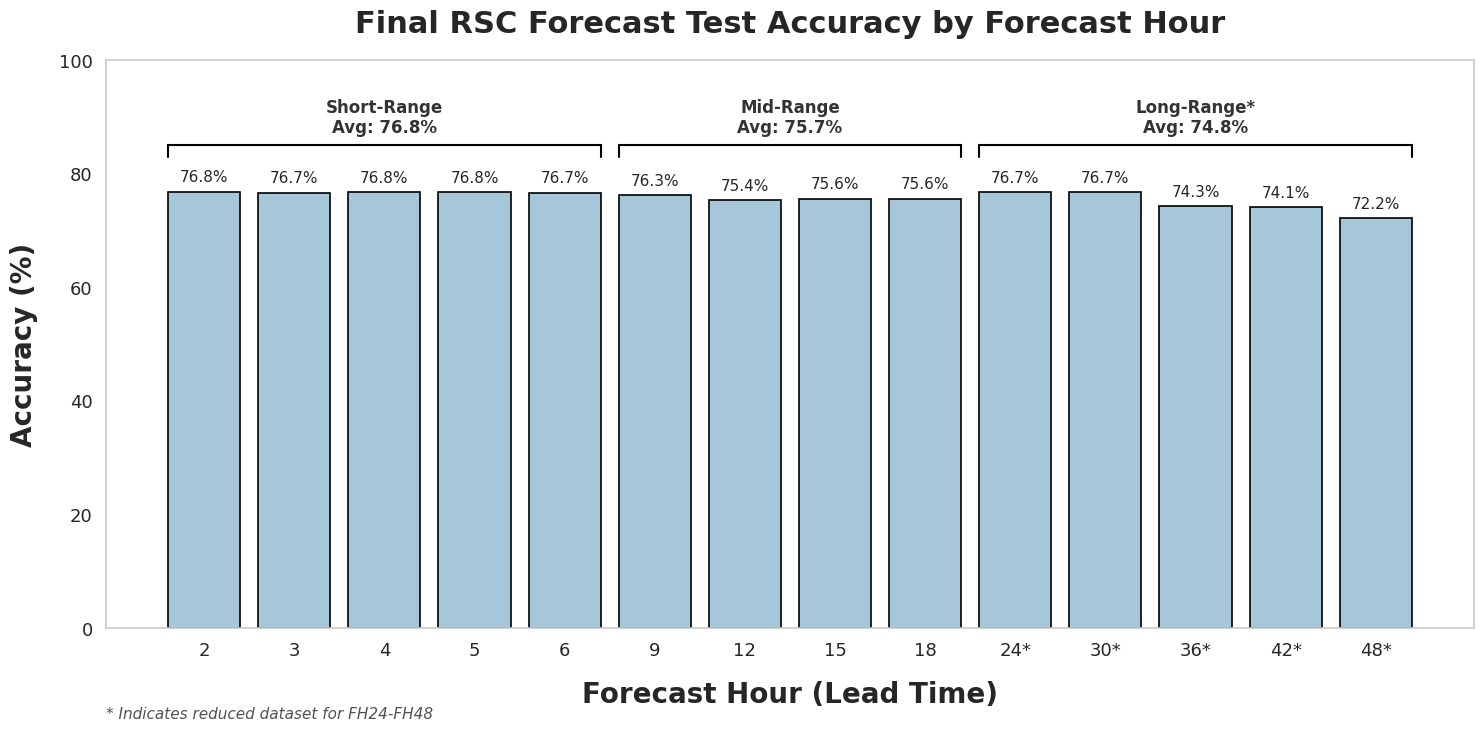

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 1. LOAD & PREP DATA
# =========================================
master_out_path = "/home/csutter/DRIVE-clean/forecasting/Master_Ensemble_Performance.csv"
df = pd.read_csv(master_out_path)

# Defensively clean the column just in case it saved with '%' signs
if df['Strict_Accuracy'].dtype == 'O':
    df['Strict_Accuracy'] = df['Strict_Accuracy'].str.rstrip('%').astype(float) / 100.0

# Ensure it's sorted chronologically and index is reset
df['Forecast_Hour'] = pd.to_numeric(df['Forecast_Hour'])
df = df.sort_values("Forecast_Hour").reset_index(drop=True)

# Convert to standard 0-100 percentages
df['Accuracy_Pct'] = df['Strict_Accuracy'] * 100

# Grouping Logic
def assign_raw_group(fh):
    if fh <= 6: return 'Short'
    elif fh <= 18: return 'Mid'
    else: return 'Long'

df['Group'] = df['Forecast_Hour'].apply(assign_raw_group)

# Calculate the macro averages
group_avgs = df.groupby('Group')['Accuracy_Pct'].mean().to_dict()

# =========================================
# 2. VISUALIZATION
# =========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7.5)) 

# Single, clean color for all bars
bar_color = '#9ecae1' 

# Generate the bar plot
ax = sns.barplot(
    data=df, 
    x='Forecast_Hour', 
    y='Accuracy_Pct', 
    color=bar_color,     
    edgecolor="black",   
    linewidth=1.2
)

# Put exact values on top of each bar
for p in ax.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue
    
    ax.annotate(f"{height:.1f}%", 
                xy=(p.get_x() + p.get_width() / 2., height),
                xytext=(0, 5),  
                textcoords='offset points',
                ha='center', va='bottom', 
                fontsize=11)

# =========================================
# 3. OVERARCHING BRACKETS & AGGREGATE STATS
# =========================================
y_bracket = 85
y_text = 86.5 

titles = {
    'Short': 'Short-Range', 
    'Mid': 'Mid-Range', 
    'Long': 'Long-Range*' 
}

for g in ['Short', 'Mid', 'Long']:
    idx_list = df[df['Group'] == g].index
    if len(idx_list) > 0:
        x_min = idx_list.min()
        x_max = idx_list.max()
        
        x_start = x_min - 0.4
        x_end = x_max + 0.4
        
        # Draw the horizontal line
        plt.plot([x_start, x_end], [y_bracket, y_bracket], color='black', lw=1.5)
        # Draw the downward "feet" of the bracket
        plt.plot([x_start, x_start], [y_bracket - 2, y_bracket], color='black', lw=1.5)
        plt.plot([x_end, x_end], [y_bracket - 2, y_bracket], color='black', lw=1.5)
        
        # Add the text label
        avg_val = group_avgs[g]
        label_text = f"{titles[g]}\nAvg: {avg_val:.1f}%"
        x_center = (x_start + x_end) / 2
        
        plt.text(x_center, y_text, label_text, ha='center', va='bottom',
                 fontsize=12, fontweight='bold', color='#333333')

# =========================================
# 4. FORMATTING & FOOTNOTE
# =========================================
plt.ylim(0, 100)
plt.yticks([0, 20, 40, 60, 80, 100], fontsize=13)

plt.title('Final RSC Forecast Test Accuracy by Forecast Hour', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Forecast Hour (Lead Time)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Accuracy (%)', fontsize=20, fontweight='bold', labelpad=15)

# Add '*' to x-axis labels for sparse data
new_labels = [f"{int(fh)}" if fh < 24 else f"{int(fh)}*" for fh in df['Forecast_Hour']]
ax.set_xticklabels(new_labels, fontsize=13)

# Remove the default gridlines above 100% so it looks clean
ax.grid(axis='y', which='major', linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# --- NEW: Add the Footnote ---
ax.annotate('* Indicates reduced dataset for FH24-FH48',
            xy=(0, -0.16), xycoords='axes fraction',
            fontsize=11, fontstyle='italic', color='#525252', ha='left')

plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix

# Confusion matrices

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os
from sklearn.metrics import confusion_matrix
from matplotlib.ticker import PercentFormatter

setFH = "02"
# =========================================
# 1. CONFUSION MATRIX PLOTTING FUNCTION
# =========================================
def cm_analysis(
    y_true,
    y_pred,
    labels,
    classes,
    ymap=None,
    figsize=(16, 14), # <-- Increased to give large fonts room to breathe
    titlename="Confusion Matrix",
):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    """
    # Use a slightly lower global scale so the boxes don't cramp, 
    # but we will manually override the titles and labels below!
    sns.set(font_scale=1.7) 

    if ymap is not None:
        y_pred = [ymap[yi] for yi in y_pred]
        y_true = [ymap[yi] for yi in y_true]
        labels = [ymap[yi] for yi in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_perc = cm / cm_sum.astype(float) * 100
        cm_perc = np.nan_to_num(cm_perc)

    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i][0]
                annot[i, j] = "%.2f%%\n%d/%d" % (p, c, s)
            else:
                annot[i, j] = "%.2f%%\n%d" % (p, c)

    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    cm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)
    cm_df = cm_df * 100
    cm_df.index.name = "True Label"
    cm_df.columns.name = "Predicted Label"

    fig, ax = plt.subplots(figsize=figsize)
    plt.yticks(va="center")
    
    # <-- RESTORED MASSIVE FONTS, REMOVED BOLDING -->
    plt.title(titlename, fontsize=50, pad=20)

    sns.heatmap(
        cm_df,
        annot=annot,
        fmt="",
        ax=ax,
        xticklabels=classes,
        cbar=True,
        cbar_kws={"format": PercentFormatter()},
        yticklabels=classes,
        cmap="Blues",
        annot_kws={"size": 22} # <-- Locks the inner box text to a perfect, readable size
    )

    ax.set_xlabel("Predicted Label", fontsize=30, labelpad=15)
    ax.set_ylabel("True Label", fontsize=30, labelpad=15)

    ax.tick_params(axis="x", labelsize=25)
    ax.tick_params(axis="y", labelsize=25)
    
    plt.tight_layout()
    plt.show()

# =========================================
# 2. DATA LOADING & FILTERING
# =========================================
files_dir = f"/home/csutter/DRIVE-clean/forecasting/data_ensembled_preds/FH{setFH}/RandomForest_details_modelFH02" # NOTE! The FH02 at the end is bc that is the TRAINED MODEL FH02-trained model. That should be the same for all
files_list = glob(os.path.join(files_dir, "*.csv"))

dfs30 = []
for f in files_list:
    d = pd.read_csv(f)
    d = d[d["outerPhase"] == "outerTest"]
    dfs30.append(d)

df = pd.concat(dfs30).reset_index(drop=True)

# =========================================
# 3. EXECUTE PLOTTING
# =========================================
y_true = df['img_cat'].values
y_pred = df['select'].values

# Use the exact raw labels for both so it matches your target image
raw_labels = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

cm_analysis(
    y_true=y_true,
    y_pred=y_pred,
    labels=raw_labels,
    classes=raw_labels, # <-- Passed raw_labels here instead of pretty names
    figsize=(16, 14),   # <-- Large canvas size
    titlename=f"Confusion Matrix - Forecast Model (FH{setFH})"
)

In [ ]:
df.head(3)

# Adjacent classes - % of wrong preds that were in an adjacent class
- Feels more meaningful to explain than a "relaxed accuracy" metric

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob

# =========================================
# 1. DATA LOADING & FILTERING
# =========================================
setFH = "02" # Change this to 09 or 24 as needed
files_dir = f"/home/csutter/DRIVE-clean/forecasting/data_ensembled_preds/FH{setFH}/RandomForest_details_modelFH02" 
files_list = glob(os.path.join(files_dir, "*.csv"))

dfs30 = []
for f in files_list:
    d = pd.read_csv(f)
    if "outerPhase" in d.columns:
        d = d[d["outerPhase"] == "outerTest"]
        if not d.empty:
            dfs30.append(d)

df = pd.concat(dfs30).reset_index(drop=True)

# Calculate it based on cols
okays_butnot_correct = sum(df["correct_relaxed"])-sum(df["correct_strict"])
totalmisses = len(df)- sum(df["correct_strict"])
# percent of all misses that are okay
print(okays_butnot_correct/totalmisses)

In [ ]:
df.head(3)

# Net gain of ensembling

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

# =========================================
# 1. DATA LOADING
# =========================================
files_dir = "/home/csutter/DRIVE-clean/forecasting/data_ensembled_preds/FH02/RandomForest_details_modelFH02"
files_list = glob.glob(os.path.join(files_dir, "*"))

dfs = []
for f in files_list:
    d = pd.read_csv(f)
    if "outerPhase" in d.columns:
        d = d[d["outerPhase"] == "outerTest"]
        if not d.empty:
            dfs.append(d)

df = pd.concat(dfs).reset_index(drop=True)

# =========================================
# 2. CALCULATE GLOBAL PERFORMANCE
# =========================================
N = len(df)
print(f"=== GLOBAL ENSEMBLE PERFORMANCE (N = {N}) ===")

# Calculate Ensemble Accuracy
ens_correct = (df['select'] == df['img_cat']).sum()
ens_acc = ens_correct / N

# Calculate Pre-Ensemble (Individual) Accuracy
m_cols = ['m0_pred', 'm1_pred', 'm2_pred', 'm3_pred', 'm4_pred']
indiv_accs = []
for m in m_cols:
    acc = (df[m] == df['img_cat']).sum() / N
    indiv_accs.append(acc)

avg_indiv_acc = np.mean(indiv_accs)

print(f"Average Pre-Ensemble Accuracy: {avg_indiv_acc * 100:.2f}%")
print(f"Final Ensemble Accuracy:       {ens_acc * 100:.2f}%")
print(f"Net Gain from Ensembling:      +{(ens_acc - avg_indiv_acc) * 100:.2f}%\n")

# =========================================
# 3. CALCULATE CLASS-LEVEL PERFORMANCE
# =========================================
print("=== CLASS-LEVEL NET GAIN ===")
classes = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

# Create a dataframe to display nicely
results = []

for c in classes:
    sub_df = df[df['img_cat'] == c]
    n_c = len(sub_df)
    
    if n_c > 0:
        # Ensemble accuracy for this class
        ens_c_acc = (sub_df['select'] == c).sum() / n_c
        
        # Pre-Ensemble accuracy for this class (summing all 5 models)
        indiv_c_correct = sum((sub_df[m] == c).sum() for m in m_cols)
        indiv_c_acc = indiv_c_correct / (n_c * 5)
        
        net_gain = ens_c_acc - indiv_c_acc
        
        results.append({
            'Class': c,
            'Support': n_c,
            'Pre-Ensemble Acc': f"{indiv_c_acc * 100:.2f}%",
            'Ensemble Acc': f"{ens_c_acc * 100:.2f}%",
            'Net Gain': f"+{net_gain * 100:.2f}%" if net_gain >= 0 else f"{net_gain * 100:.2f}%"
        })

results_df = pd.DataFrame(results)
display(results_df)